# 06. Evaluation Expansion

Continuing from `cleaned_preprocessed_data.csv` (02_preprocessing.ipynb, including the Week 6 engineered features) and the three models compared in 05_advanced_models.ipynb (`LinearRegression`, `RandomForest (max_depth=5)`, `XGBoost (tuned)`).

R2 and RMSE tell us how a model does *on average in dollar terms*, but they're dominated by a handful of large-dollar errors on expensive properties (see 04_model_comparison.ipynb / 05_advanced_models.ipynb. RMSE was consistently much worse than MAE for the tree-based models). This notebook adds two percentage-based metrics that are easier to interpret business-wise and less skewed by a few extreme-dollar errors:

- **MAPE** (Mean Absolute Percentage Error): average of `|actual - predicted| / actual`, as a percentage
- **MdAPE** (Median Absolute Percentage Error): same idea, but the *median* instead of the mean - much less sensitive to a handful of badly-mispriced outliers

It also breaks results down **by price band**, to check directly whether the tree-based models' weakness really is concentrated in the high-price tail, as suspected in earlier notebooks.


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

try:
    from xgboost import XGBRegressor
except ImportError as e:
    raise ImportError(
        "This notebook needs xgboost. Install with: pip install xgboost "
    ) from e

RANDOM_STATE = 42


## 1. Load cleaned dataset


In [7]:
cleaned_df = pd.read_csv("cleaned_preprocessed_data.csv", low_memory=False)
print(cleaned_df.shape)
cleaned_df["split"].value_counts()


(83495, 121)


split
train     59442
unused    12029
test      12024
Name: count, dtype: int64

## 2. Separate features / target using the `split` column

Same pattern as the previous notebooks: `split == "train"` for training, `split == "test"` for the held-out final evaluation.


In [8]:
target = "ClosePrice"
meta_cols = [target, "date", "year_month", "split"]

train_df = cleaned_df[cleaned_df["split"] == "train"].copy()
test_df = cleaned_df[cleaned_df["split"] == "test"].copy()

feature_cols = [c for c in cleaned_df.columns if c not in meta_cols]

X_train = train_df[feature_cols]
y_train = train_df[target]

X_test = test_df[feature_cols]
y_test = test_df[target]

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")


X_train: (59442, 117) | X_test: (12024, 117)


## 3. Train the three models

Re-trained here (rather than reloading saved models) so this notebook stays self-contained and reproducible on its own. `RandomForest (max_depth=5)` and XGBoost's hyperparameters are the winning settings found in 04_model_comparison.ipynb / 05_advanced_models.ipynb, not re-tuned here 

In [9]:
# XGBoost hyperparameters carried over from 05_advanced_models.ipynb's light hyperparameter search
XGB_BEST_PARAMS = {"max_depth": 7, "learning_rate": 0.05, "n_estimators": 200}

models = {
    "LinearRegression": LinearRegression(),
    "RandomForest (max_depth=5)": RandomForestRegressor(max_depth=5, random_state=RANDOM_STATE, n_jobs=-1),
    "XGBoost (tuned)": XGBRegressor(**XGB_BEST_PARAMS, random_state=RANDOM_STATE, n_jobs=-1),
}

predictions = {} 

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)
    print(f"{name}: fitted")


LinearRegression: fitted
RandomForest (max_depth=5): fitted
XGBoost (tuned): fitted


## 4. Metrics beyond R2: MAPE and MdAPE

scikit-learn doesn't ship a median-based percentage error metric, so both are defined directly. Rows where the actual price is 0 are guarded against (division by zero) - `ClosePrice` shouldn't ever be 0 given the target-cleaning in 02_preprocessing.ipynb, but the guard costs nothing and makes the function safe to reuse elsewhere.


In [10]:
def mape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0 # creating `mask` to extact non-zero values 
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 # caculating without zero values.


def mdape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    mask = y_true != 0
    return np.median(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def evaluate_full(y_true, y_pred):
    return {
        "R2": r2_score(y_true, y_pred),
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE": mape(y_true, y_pred),
        "MdAPE": mdape(y_true, y_pred),
    }


## 5. Overall metrics per model


In [11]:
overall_rows = []
for name, pred in predictions.items():
    row = {"model": name, "price_band": "Overall", "n_rows": len(y_test)}
    row.update(evaluate_full(y_test, pred))
    overall_rows.append(row)

overall_df = pd.DataFrame(overall_rows).sort_values("MdAPE").reset_index(drop=True)
overall_df


,model,price_band,n_rows,R2,MAE,RMSE,MAPE,MdAPE
0,XGBoost (tuned),Overall,12024,-1.243778,178624.312462,2.513608e+06,19.796201,3.450577
1,RandomForest (max_depth=5),Overall,12024,-1.127638,226927.757627,2.447690e+06,29.477244,10.755461
2,LinearRegression,Overall,12024,0.607554,256231.962885,1.051229e+06,29.917059,14.270831


## 6. Which price bands perform better?

The test set is split into 5 roughly equal-sized price bands (quintiles of the actual `ClosePrice`, so each band has a similar number of properties). MAPE/MdAPE/RMSE are computed separately within each band for every model, to see whether errors really do concentrate in the high-price tail as suspected in 04_model_comparison.ipynb / 05_advanced_models.ipynb.


In [12]:
N_PRICE_BANDS = 5

price_bands = pd.qcut(y_test, q=N_PRICE_BANDS)
band_labels = [f"${int(b.left):,} - ${int(b.right):,}" for b in price_bands.cat.categories]
price_band_series = price_bands.cat.rename_categories(band_labels)

band_rows = []
for name, pred in predictions.items():
    for band in band_labels:
        band_mask = (price_band_series == band).values
        if band_mask.sum() == 0:
            continue
        row = {"model": name, "price_band": band, "n_rows": int(band_mask.sum())}
        row.update(evaluate_full(y_test[band_mask], pred[band_mask]))
        band_rows.append(row)

band_df = pd.DataFrame(band_rows)
band_df


,model,price_band,n_rows,R2,MAE,RMSE,MAPE,MdAPE
0,LinearRegression,"$11,899 - $580,000",2422,-6.153935,172800.068767,2.802051e+05,58.750397,28.544495
1,LinearRegression,"$580,000 - $807,500",2389,-41.057973,242293.049253,4.244303e+05,34.851738,18.788894
2,LinearRegression,"$807,500 - $1,125,000",2433,-20.742781,252760.929236,4.244776e+05,27.080883,14.397845
3,LinearRegression,"$1,125,000 - $1,690,000",2383,-4.484525,235542.341249,3.699574e+05,17.376631,10.463229
4,LinearRegression,"$1,690,000 - $97,972,500",2397,0.479088,378518.364827,2.228354e+06,11.210745,7.803858
5,RandomForest (max_depth=5),"$11,899 - $580,000",2422,-36.532875,176740.740867,6.418144e+05,69.662187,27.228439
6,RandomForest (max_depth=5),"$580,000 - $807,500",2389,-61.110032,195784.721570,5.157783e+05,28.169146,18.540154
7,RandomForest (max_depth=5),"$807,500 - $1,125,000",2433,-836.091793,195632.008327,2.633806e+06,21.813196,6.310832
8,RandomForest (max_depth=5),"$1,125,000 - $1,690,000",2383,-642.185950,262963.445897,4.006364e+06,19.012808,10.104139
9,RandomForest (max_depth=5),"$1,690,000 - $97,972,500",2397,0.331367,304617.862187,2.524622e+06,8.359388,4.796801


## 7. Visualize price-band performance

MdAPE (robust to outliers) is plotted alongside RMSE (sensitive to outliers) for the same price bands, side by side - the contrast between the two is the clearest way to see whether a model's high-price-band weakness is really about typical accuracy or about a few extreme misses.


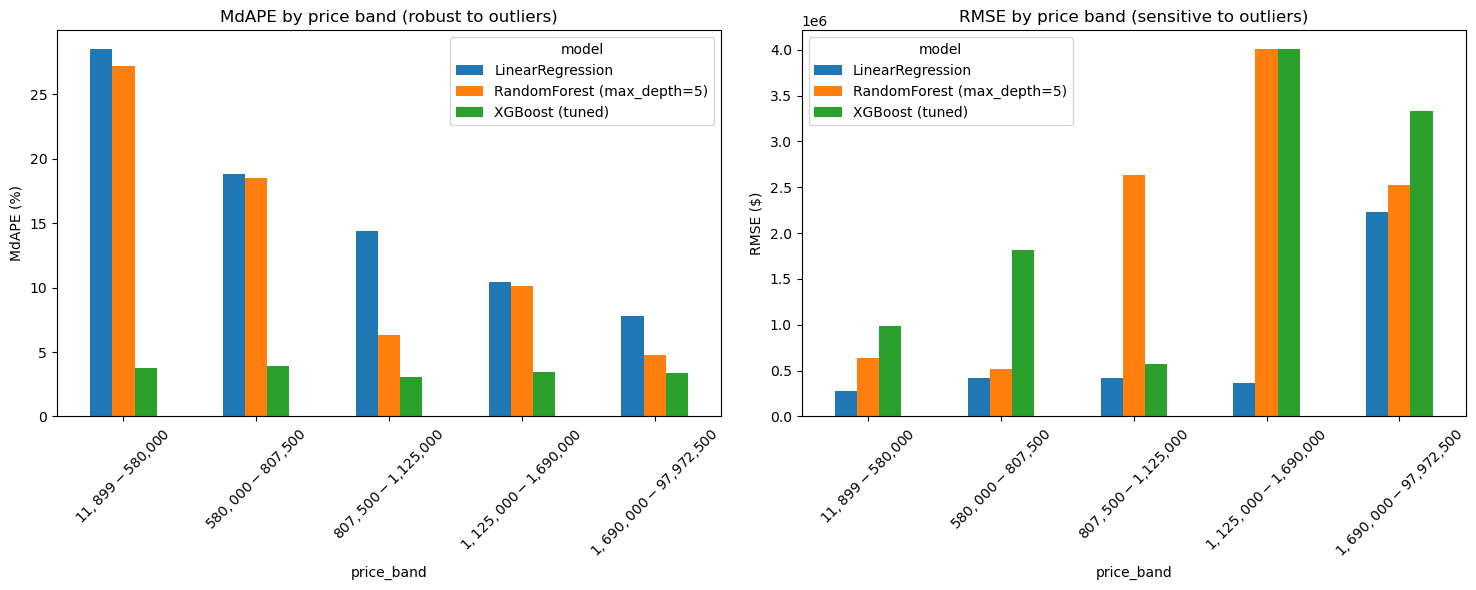

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

pivot_mdape = band_df.pivot(index="price_band", columns="model", values="MdAPE").loc[band_labels]
pivot_mdape.plot(kind="bar", ax=axes[0])
axes[0].set_title("MdAPE by price band (robust to outliers)")
axes[0].set_ylabel("MdAPE (%)")
axes[0].tick_params(axis="x", rotation=45)

pivot_rmse = band_df.pivot(index="price_band", columns="model", values="RMSE").loc[band_labels]
pivot_rmse.plot(kind="bar", ax=axes[1])
axes[1].set_title("RMSE by price band (sensitive to outliers)")
axes[1].set_ylabel("RMSE ($)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


## 8. Insights summary & save `metrics_summary.csv`

Combines the overall metrics (section 5) and the per-price-band breakdown (section 6) into one long-format table - `price_band == "Overall"` rows give the whole-test-set numbers, and the rest give the quintile breakdown.


In [14]:
metrics_summary = pd.concat([overall_df, band_df], ignore_index=True)
metrics_summary = metrics_summary[["model", "price_band", "n_rows", "R2", "MAE", "RMSE", "MAPE", "MdAPE"]]

metrics_summary.to_csv("metrics_summary.csv", index=False)
print("Saved metrics_summary.csv")
metrics_summary


Saved metrics_summary.csv


,model,price_band,n_rows,R2,MAE,RMSE,MAPE,MdAPE
0,XGBoost (tuned),Overall,12024,-1.243778,178624.312462,2.513608e+06,19.796201,3.450577
1,RandomForest (max_depth=5),Overall,12024,-1.127638,226927.757627,2.447690e+06,29.477244,10.755461
2,LinearRegression,Overall,12024,0.607554,256231.962885,1.051229e+06,29.917059,14.270831
3,LinearRegression,"$11,899 - $580,000",2422,-6.153935,172800.068767,2.802051e+05,58.750397,28.544495
4,LinearRegression,"$580,000 - $807,500",2389,-41.057973,242293.049253,4.244303e+05,34.851738,18.788894
5,LinearRegression,"$807,500 - $1,125,000",2433,-20.742781,252760.929236,4.244776e+05,27.080883,14.397845
6,LinearRegression,"$1,125,000 - $1,690,000",2383,-4.484525,235542.341249,3.699574e+05,17.376631,10.463229
7,LinearRegression,"$1,690,000 - $97,972,500",2397,0.479088,378518.364827,2.228354e+06,11.210745,7.803858
8,RandomForest (max_depth=5),"$11,899 - $580,000",2422,-36.532875,176740.740867,6.418144e+05,69.662187,27.228439
9,RandomForest (max_depth=5),"$580,000 - $807,500",2389,-61.110032,195784.721570,5.157783e+05,28.169146,18.540154


## Summary

**Overall metrics (section 5):**

- R2 ranks Linear Regression first and XGBoost last, but that's flipped once outlier-robust `MdAPE` is used instead: **XGBoost's median error (3.45%) is roughly 4x better than Linear Regression's (14.27%)**. This confirms XGBoost's weak R2/RMSE is driven by a handful of skewed properties, not by broad inaccuracy. Thus, On a typical-case basis it's by far the most accurate of the three models

**Price-band breakdown (section 6-7), MdAPE by quintile:**

- The earlier assumption that Linear Regression and Random Forest struggle specifically with the *high*-price tail doesn't hold up once errors are measured in percentage terms: both are actually **least accurate in the lowest price band** (LR 28.5%, RF 27.2%) and get proportionally more accurate as price increases. A fixed-dollar error simply represents a much larger percentage of a cheaper home's price, so this looks like heteroscedasticity in the underlying price-vs-error relationship rather than a tree-depth issue
- **XGBoost's MdAPE stays flat (3.06%-3.89%) across every price band**, unlike Linear Regression's and Random Forest's 4-7x swing between the cheapest and most expensive bands. XGBoost isn't just more accurate overall, it's also the most *consistent* across the price spectrum
- Within-band `MAE` vs `RMSE` still diverge sharply for the tree-based models. So, the extreme-dollar-error problem isn't confined to one price segment. It recurs inside every band, just outweighed there by otherwise-accurate predictions
- **Caveat**: R2 computed within a narrow price band is not reliable and shouldn't be read the way overall R2 is - restricting the range shrinks the variance in the denominator, so the same absolute errors produce wildly exaggerated R2 swings. `MAPE`/`MdAPE` don't have this problem since they're per-row percentage ratios rather than variance-normalized.

- Deliverables: `metrics_summary.csv` (overall + per-price-band metrics for all three models), this notebook (`06_evaluation.ipynb`)
